<a href="https://colab.research.google.com/github/VadimFilips/ProjectFilipsGit/blob/main/%D0%97%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5%20%E2%84%963/%D0%97%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_%E2%84%963.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving fixtures.csv to fixtures (10).csv
Матчи Манчестер Юнайтед:
   week  Day        Date   Time            Home  HomeScore            Away  \
0   1.0  Fri  2024-08-16  20:00  Manchester Utd          1          Fulham   
1   2.0  Sat  2024-08-24  12:30        Brighton          2  Manchester Utd   
2   3.0  Sun  2024-09-01  16:00  Manchester Utd          0       Liverpool   
3   4.0  Sat  2024-09-14  12:30     Southampton          0  Manchester Utd   
4   5.0  Sat  2024-09-21  17:30  Crystal Palace          0  Manchester Utd   

   AwayScore  Attendance                         Venue         Referee  
0          0     73297.0                  Old Trafford    Robert Jones  
1          1     31537.0  The American Express Stadium    Craig Pawson  
2          3     73738.0                  Old Trafford  Anthony Taylor  
3          3     31144.0             St Mary's Stadium  Stuart Attwell  
4          0     25172.0                 Selhurst Park     David Coote  


Матчи Челси:
   week  Day

,avg_attendance,max_attendance,min_attendance
0,40431.26,"73,839","11,129"



Основные показатели посещаемости:
Средняя посещаемость: 40,431.26 зрителей
Максимальная посещаемость: 73,839 зрителей
Минимальная посещаемость: 11,129 зрителей


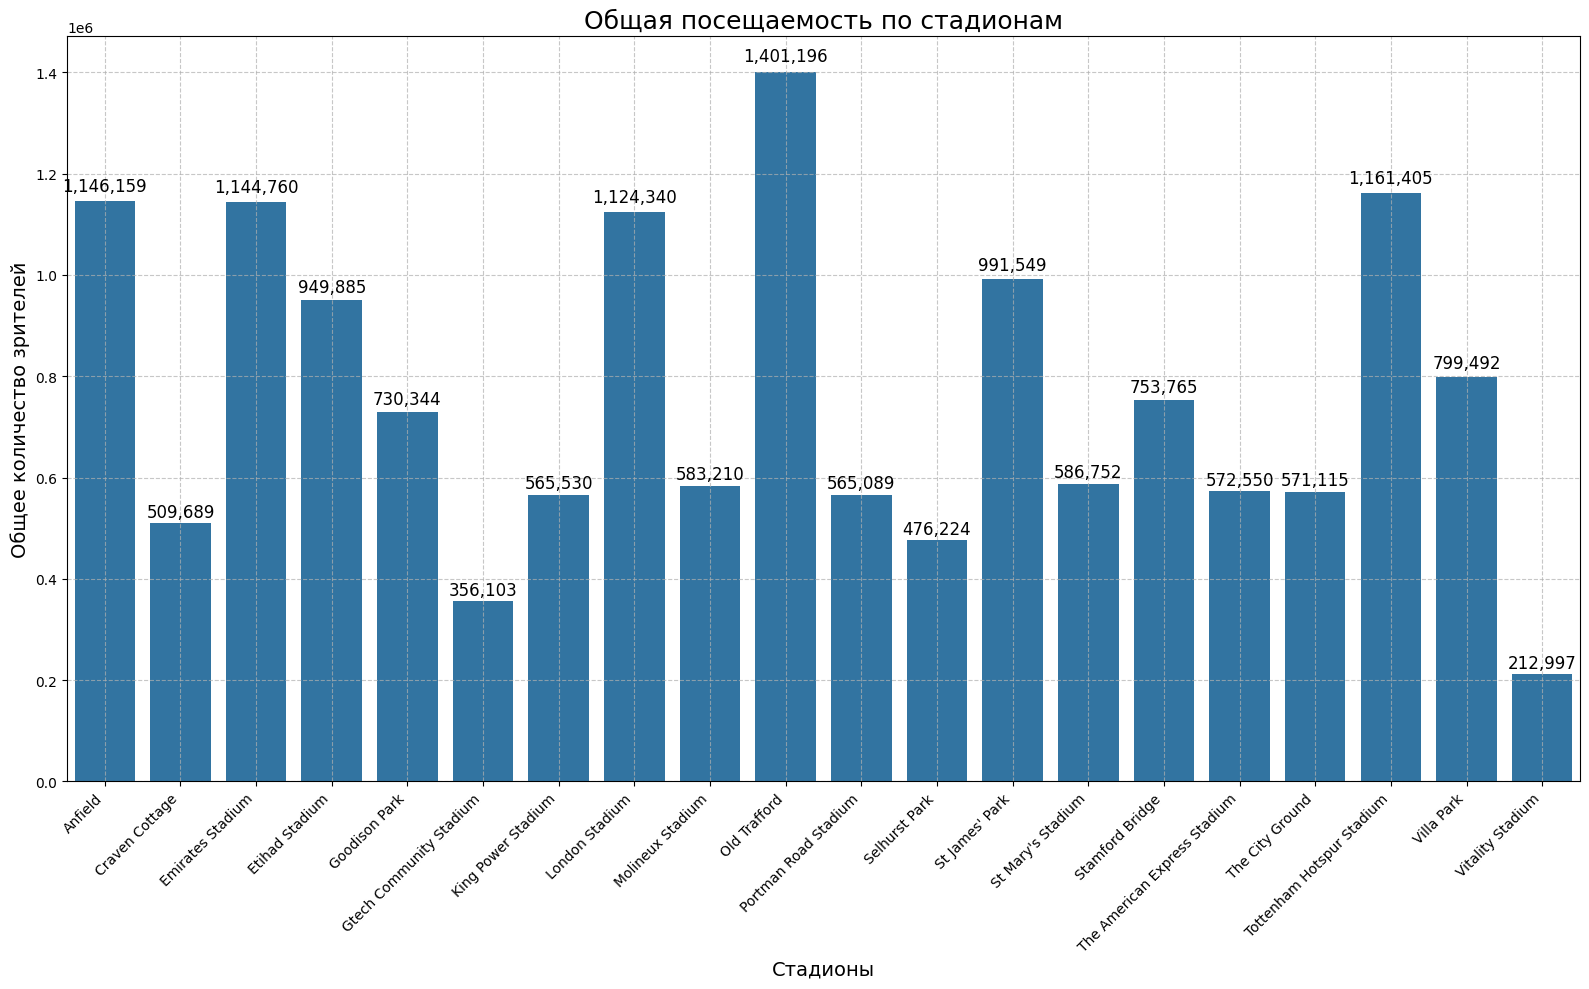

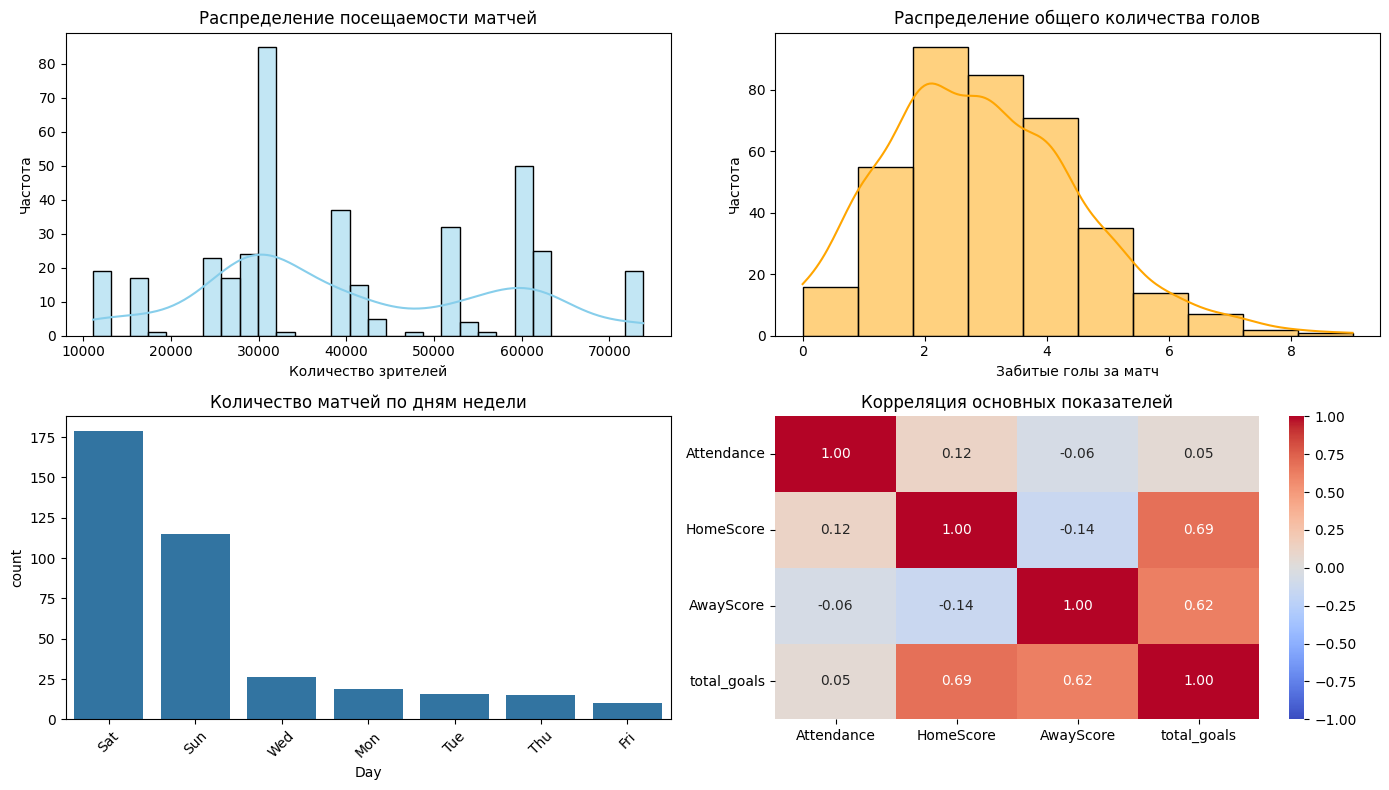

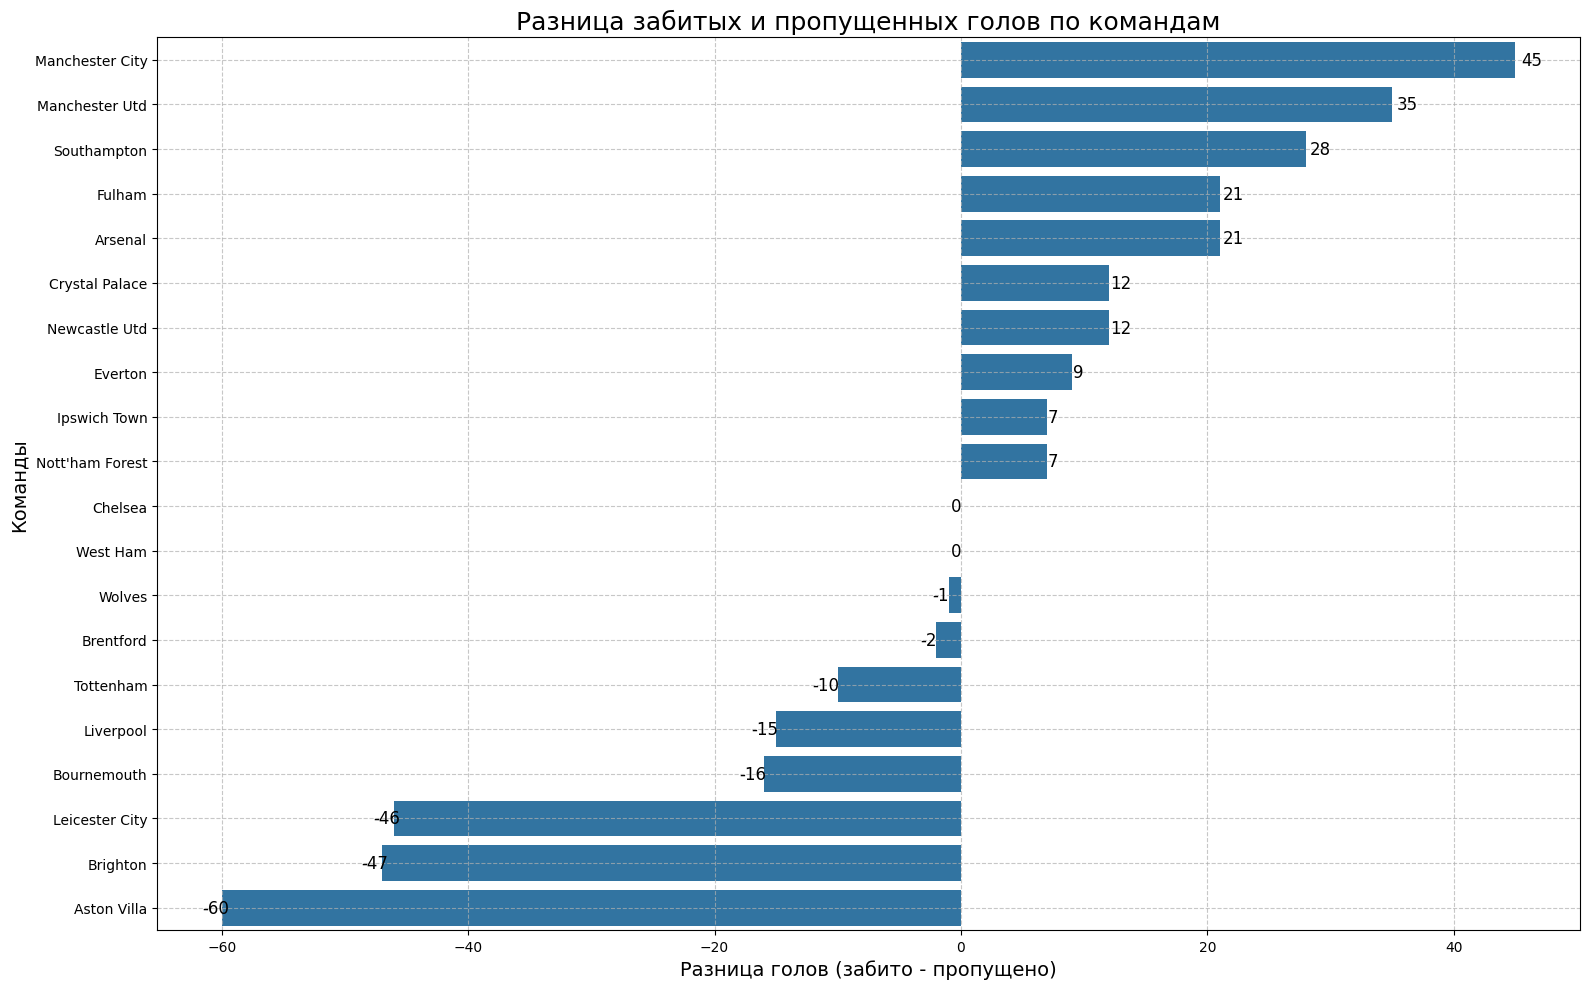

In [11]:

# Импортируем необходимые библиотеки
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Загружаем датасет
uploaded = files.upload()
df = pd.read_csv('fixtures.csv')

# Создаем подключение к SQLite базе данных
conn = sqlite3.connect('football_matches.db')

# Создаем таблицу
cursor = conn.cursor()

create_table_query = """
CREATE TABLE IF NOT EXISTS matches (
    week REAL,
    Day TEXT,
    Date DATE,
    Time TIME,
    Home TEXT,
    HomeScore INTEGER,
    Away TEXT,
    AwayScore INTEGER,
    Attendance REAL,
    Venue TEXT,
    Referee TEXT
);
"""

cursor.execute(create_table_query)
conn.commit()

# Загружаем данные из DataFrame в таблицу
df.to_sql('matches', conn, if_exists='replace', index=False)

# Определяем функцию для выполнения запросов
def execute_query(query):
    cursor.execute(query)
    return cursor.fetchall()

# Запрос для Манчестер Юнайтед
query_manchester = """
SELECT * FROM matches
WHERE Home = 'Manchester Utd' OR Away = 'Manchester Utd'
LIMIT 5
"""

# Запрос для Челси
query_chelsea = """
SELECT * FROM matches
WHERE Home = 'Chelsea' OR Away = 'Chelsea'
LIMIT 10
"""

# Выполняем запросы и выводим результаты
print("Матчи Манчестер Юнайтед:")
manchester_df = pd.read_sql_query(query_manchester, conn)
print(manchester_df)
print("\n\nМатчи Челси:")
chelsea_df = pd.read_sql_query(query_chelsea, conn)
print(chelsea_df)

# Анализ посещаемости

# Выполняем запрос и преобразуем в DataFrame
query_avg_attendance = """
SELECT
    AVG(attendance) as avg_attendance,
    MAX(attendance) as max_attendance,
    MIN(attendance) as min_attendance
FROM matches
"""

# Получаем данные
attendance_stats = pd.read_sql_query(query_avg_attendance, conn)

# Темный фон
formatted_stats = attendance_stats.style\
    .format({'avg_attendance': '{:.2f}',
             'max_attendance': '{:,.0f}',
             'min_attendance': '{:,.0f}'})\
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center'),
                                    ('background-color', '#2c3e50'),
                                    ('color', 'white')]},
        {'selector': 'td', 'props': [('text-align', 'right'),
                                    ('background-color', '#34495e'),
                                    ('color', 'white')]}
    ])\
    .set_caption('Статистика посещаемости матчей')\
    .set_table_styles([dict(selector='th', props=[('border', '1px solid #ecf0f1')])])

# Выводим результат
display(formatted_stats)

# Текстовая интерпретация
print("\nОсновные показатели посещаемости:")
print(f"Средняя посещаемость: {attendance_stats['avg_attendance'][0]:,.2f} зрителей")
print(f"Максимальная посещаемость: {attendance_stats['max_attendance'][0]:,.0f} зрителей")
print(f"Минимальная посещаемость: {attendance_stats['min_attendance'][0]:,.0f} зрителей")

# создаем DataFrame с суммарной посещаемостью по стадионам
stadium_attendance = df.groupby('Venue')['Attendance'].sum().reset_index()
stadium_attendance.rename(columns={'Attendance': 'total_attendance'}, inplace=True)

#  создаем DataFrame с данными по командам

team_stats = pd.concat([
    df.groupby('Home').agg({'HomeScore': 'sum', 'AwayScore': 'sum'})
     .rename(columns={'HomeScore': 'goals_for', 'AwayScore': 'goals_against'})
     .reset_index(),  # Добавляем reset_index()

    df.groupby('Away').agg({'HomeScore': 'sum', 'AwayScore': 'sum'})
     .rename(columns={'HomeScore': 'goals_against', 'AwayScore': 'goals_for'})
     .reset_index()  # Добавляем reset_index()
], ignore_index=True)  # Объединяем без сохранения индексов

# Создаем единый список команд
all_teams = pd.concat([df['Home'], df['Away']]).unique()

# Группируем по командам
team_stats = team_stats.groupby('Home').sum().reset_index()

# Альтернативный способ (более надежный)
team_stats = pd.DataFrame({
    'team': all_teams,
    'goals_for': df.groupby('Home')['HomeScore'].sum().add(
        df.groupby('Away')['AwayScore'].sum(), fill_value=0
    ),
    'goals_against': df.groupby('Home')['AwayScore'].sum().add(
        df.groupby('Away')['HomeScore'].sum(), fill_value=0
    )
}).reset_index(drop=True)

# Считаем разницу голов
team_stats['goal_difference'] = team_stats['goals_for'] - team_stats['goals_against']

# Сортируем по разнице голов
team_stats_sorted = team_stats.sort_values(
    by='goal_difference',
    ascending=False
).reset_index(drop=True)

# Закрываем соединение в конце работы
conn.close()

# Визуализация

# Создаем график посещаемости по стадионам
plt.figure(figsize=(16, 10))
sns.barplot(
    x='Venue',
    y='total_attendance',
    data=stadium_attendance
)

plt.title('Общая посещаемость по стадионам', fontsize=18)
plt.xlabel('Стадионы', fontsize=14)
plt.ylabel('Общее количество зрителей', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Добавляем значения посещаемости над столбцами
for p in plt.gca().patches:
    value = int(p.get_height())
    plt.gca().annotate(f'{value:,}',  # Добавляем разделители тысяч
                      (p.get_x() + p.get_width() / 2,
                       p.get_height() * 1.01),
                      ha='center', va='bottom',
                      fontsize=12, color='black')

plt.show()

# 1. Общая статистика посещаемости
plt.figure(figsize=(14, 8))

# Распределение посещаемости
plt.subplot(2, 2, 1)
sns.histplot(df['Attendance'], bins=30, kde=True, color='skyblue')
plt.title('Распределение посещаемости матчей')
plt.xlabel('Количество зрителей')
plt.ylabel('Частота')

# 2. Анализ результативности матчей
plt.subplot(2, 2, 2)
df['total_goals'] = df['HomeScore'] + df['AwayScore']
sns.histplot(df['total_goals'], bins=10, kde=True, color='orange')
plt.title('Распределение общего количества голов')
plt.xlabel('Забитые голы за матч')
plt.ylabel('Частота')

# 3. Анализ матчей по дням недели
plt.subplot(2, 2, 3)
sns.countplot(
    x='Day',
    data=df,
    order=df['Day'].value_counts().index
)
plt.title('Количество матчей по дням недели')
plt.xticks(rotation=45)

# 4. Тепловая карта корреляций основных показателей
plt.subplot(2, 2, 4)
correlation_matrix = df[['Attendance', 'HomeScore', 'AwayScore', 'total_goals']].corr()
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    vmin=-1,
    vmax=1
)
plt.title('Корреляция основных показателей')

plt.tight_layout()
plt.show()

# Создаем график разницы голов

plt.figure(figsize=(16, 10))
sns.barplot(
    x='goal_difference',
    y='team',
    data=team_stats_sorted,
    order=team_stats_sorted['team']
)

plt.title('Разница забитых и пропущенных голов по командам', fontsize=18)
plt.xlabel('Разница голов (забито - пропущено)', fontsize=14)
plt.ylabel('Команды', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Добавляем значения разницы голов
for p in plt.gca().patches:
    value = int(p.get_width())
    if value > 0:
        plt.gca().annotate(str(value),
                          (p.get_width() * 1.01, p.get_y() + p.get_height() / 2),
                          ha='left', va='center', fontsize=12)
    else:
        plt.gca().annotate(str(value),
                          (p.get_width() * 0.99, p.get_y() + p.get_height() / 2),
                          ha='right', va='center', fontsize=12)

plt.show()
